<a href="https://colab.research.google.com/github/yo-rk/Adaptive-gpu-optimizer/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ABIS-RUU – Baseline GPU Behaviour Experiment

This notebook implements:

• CNN training on CIFAR-10  
• Real-time GPU telemetry monitoring using NVML  
• Batch-size scaling experiment (128 vs 256)  
• GPU utilization and memory comparison  

Objective:
To analyze baseline GPU behaviour and observe how workload scaling impacts resource utilization.


## 1. Environment Setup



In [2]:
!nvidia-smi
!pip install nvidia-ml-py3


Sun Apr 19 12:47:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Library Imports & Device Configuration

Importing PyTorch, TorchVision, and setting up CUDA device.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. GPU Telemetry Initialization

Initializing NVIDIA Management Library (NVML) for real-time GPU monitoring.


In [4]:
from pynvml import *
import time
import csv

nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)


## 4. Dataset Preparation

Loading CIFAR-10 dataset and applying preprocessing transformations.


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)


100%|██████████| 170M/170M [00:04<00:00, 41.9MB/s]


#Dataset Inspection



In [6]:
print("Number of training samples:", len(trainset))

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Number of test samples:", len(testset))

image, label = trainset[0]
print("Image shape:", image.shape)
print("Label:", label)

Number of training samples: 50000
Number of test samples: 10000
Image shape: torch.Size([3, 32, 32])
Label: 6


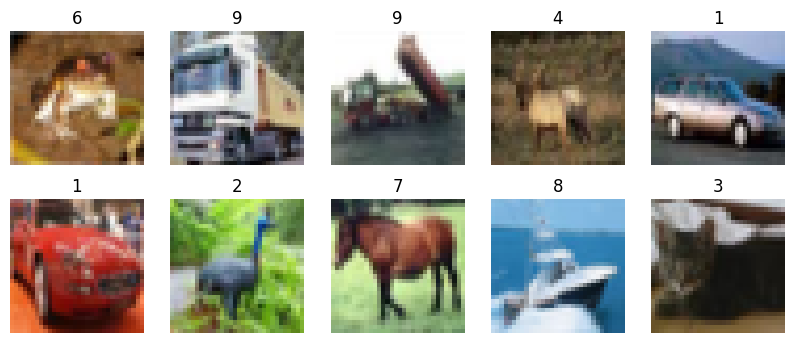

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    image, label = trainset[i]
    ax.imshow(image.permute(1,2,0))
    ax.set_title(label)
    ax.axis("off")

plt.show()

## 5. CNN Model Architecture

Defining a simple convolutional neural network for image classification.


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)


## 6. Training Configuration

Defining loss function and optimization strategy.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 7. Experimental Framework

Running controlled batch-size experiments while logging GPU utilization and memory usage.


In [10]:
def run_experiment(initial_batch_size, mode="static"):

    print(f"\nStarting experiment | Mode: {mode} | Initial Batch Size: {initial_batch_size}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SimpleCNN().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    current_batch_size = initial_batch_size

    log_filename = f"{mode}_bs_{initial_batch_size}.csv"

    # 🔥 NEW: for smoothing + control
    util_history = []
    cooldown = 0

    # 🔥 NEW: dynamic memory threshold
    if torch.cuda.is_available():
        total_mem = nvmlDeviceGetMemoryInfo(handle).total / 1024**2
    else:
        total_mem = 0

    with open(log_filename, "w", newline="") as file:
        writer = csv.writer(file)

        writer.writerow(["Time", "GPU_Util", "Memory_MB", "Batch_Size"])

        for epoch in range(3):
            print(f"\nEpoch {epoch+1}/3")

            trainloader = torch.utils.data.DataLoader(
                trainset, batch_size=current_batch_size, shuffle=True
            )

            for i, data in enumerate(trainloader, 0):

                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                # 🔥 GPU metrics
                if torch.cuda.is_available():
                    util = nvmlDeviceGetUtilizationRates(handle).gpu
                    mem = nvmlDeviceGetMemoryInfo(handle).used / 1024**2
                else:
                    util, mem = 0, 0

                # 🔥 NEW: moving average
                util_history.append(util)
                if len(util_history) > 10:
                    util_history.pop(0)

                avg_util = sum(util_history) / len(util_history)

                # 🔥 Log data
                writer.writerow([
                    time.time(),
                    util,
                    mem,
                    current_batch_size
                ])

                # 🔥 CORE: Adaptive logic (improved)
                if mode == "adaptive":

                    if cooldown == 0:
                        new_batch_size = current_batch_size

                        if avg_util < 50:
                            new_batch_size = min(current_batch_size + 16, 256)

                        elif total_mem > 0 and mem > 0.8 * total_mem:
                            new_batch_size = max(current_batch_size - 16, 16)

                        if new_batch_size != current_batch_size:
                            print(f"Batch size changed: {current_batch_size} → {new_batch_size}")
                            current_batch_size = new_batch_size
                            cooldown = 20   # 🔥 wait before next change
                    else:
                        cooldown -= 1

                # 🔥 Better debug output
                if i % 100 == 99:
                    print(f"[Batch {i+1}] GPU: {util}% (avg: {avg_util:.2f}) | Mem: {mem:.2f} MB | BS: {current_batch_size}")

    print(f"Finished experiment → {log_filename}")

## 8. Comparative Analysis

Loading telemetry logs and comparing GPU utilization and memory usage across configurations.


In [11]:
import os
print(os.listdir())

['.config', 'data', 'sample_data']


In [12]:
run_experiment(16, "static")
run_experiment(32, "static")
run_experiment(64, "static")
run_experiment(128, "static")

run_experiment(32, "adaptive")


Starting experiment | Mode: static | Initial Batch Size: 16

Epoch 1/3
[Batch 100] GPU: 19% (avg: 18.60) | Mem: 622.19 MB | BS: 16
[Batch 200] GPU: 17% (avg: 17.20) | Mem: 622.19 MB | BS: 16
[Batch 300] GPU: 18% (avg: 18.00) | Mem: 622.19 MB | BS: 16
[Batch 400] GPU: 18% (avg: 18.00) | Mem: 622.19 MB | BS: 16
[Batch 500] GPU: 18% (avg: 18.00) | Mem: 622.19 MB | BS: 16
[Batch 600] GPU: 19% (avg: 19.00) | Mem: 622.19 MB | BS: 16
[Batch 700] GPU: 17% (avg: 17.00) | Mem: 622.19 MB | BS: 16
[Batch 800] GPU: 19% (avg: 19.00) | Mem: 622.19 MB | BS: 16
[Batch 900] GPU: 19% (avg: 19.00) | Mem: 622.19 MB | BS: 16
[Batch 1000] GPU: 20% (avg: 20.00) | Mem: 622.19 MB | BS: 16
[Batch 1100] GPU: 15% (avg: 15.00) | Mem: 622.19 MB | BS: 16
[Batch 1200] GPU: 5% (avg: 7.40) | Mem: 622.19 MB | BS: 16
[Batch 1300] GPU: 7% (avg: 5.80) | Mem: 622.19 MB | BS: 16
[Batch 1400] GPU: 8% (avg: 9.20) | Mem: 622.19 MB | BS: 16
[Batch 1500] GPU: 12% (avg: 12.00) | Mem: 622.19 MB | BS: 16
[Batch 1600] GPU: 20% (avg: 

In [15]:
import pandas as pd

df_16 = pd.read_csv("static_bs_16.csv")
df_32 = pd.read_csv("static_bs_32.csv")
df_64 = pd.read_csv("static_bs_64.csv")
df_128 = pd.read_csv("static_bs_128.csv")

df_adaptive = pd.read_csv("adaptive_bs_32.csv")

Graph 1: Static GPU Utilization Comparison

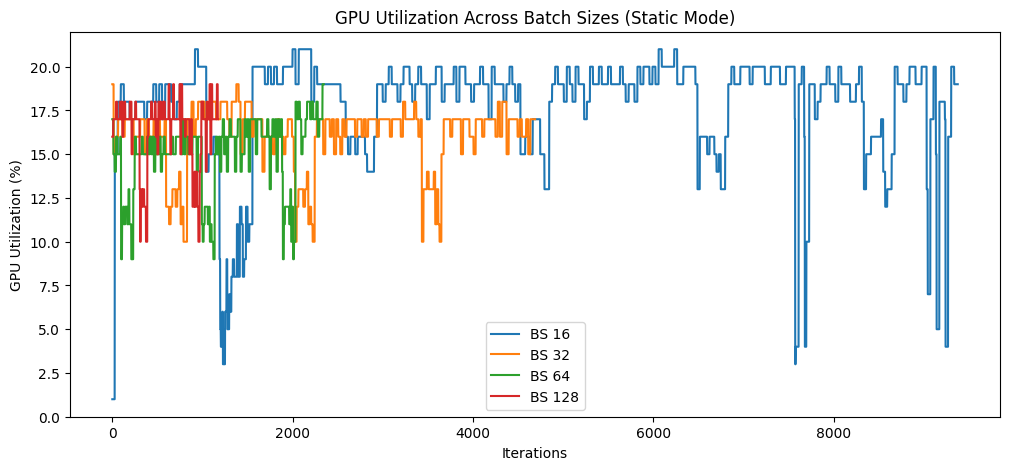

In [16]:
# ===============================
# Graph 1: Static GPU Utilization Comparison
# ===============================

plt.figure(figsize=(12,5))

plt.plot(df_16["GPU_Util"], label="BS 16")
plt.plot(df_32["GPU_Util"], label="BS 32")
plt.plot(df_64["GPU_Util"], label="BS 64")
plt.plot(df_128["GPU_Util"], label="BS 128")

plt.xlabel("Iterations")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Across Batch Sizes (Static Mode)")
plt.legend()

plt.show()


Graph 2: Static Memory Usage Comparison

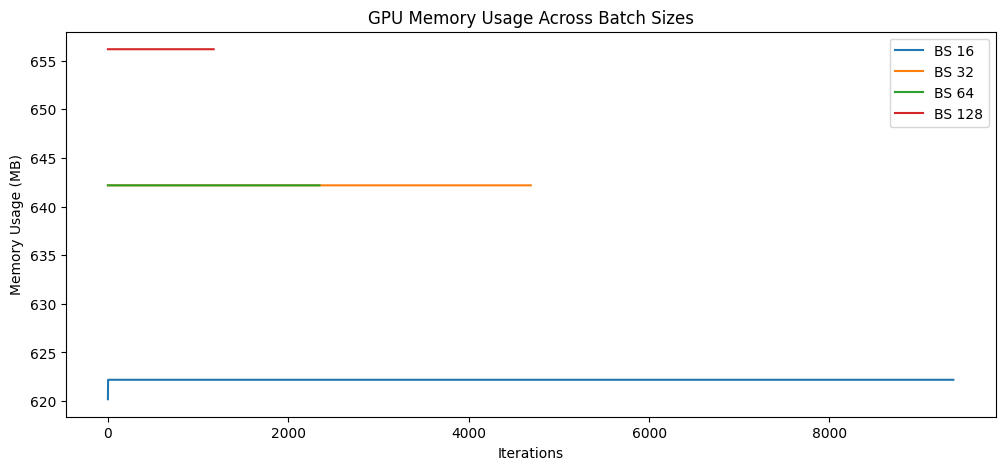

In [17]:
# ===============================
# Graph 2: Static Memory Usage Comparison
# ===============================

plt.figure(figsize=(12,5))

plt.plot(df_16["Memory_MB"], label="BS 16")
plt.plot(df_32["Memory_MB"], label="BS 32")
plt.plot(df_64["Memory_MB"], label="BS 64")
plt.plot(df_128["Memory_MB"], label="BS 128")

plt.xlabel("Iterations")
plt.ylabel("Memory Usage (MB)")
plt.title("GPU Memory Usage Across Batch Sizes")
plt.legend()

plt.show()

Graph 3: Adaptive GPU Utilization Over Time

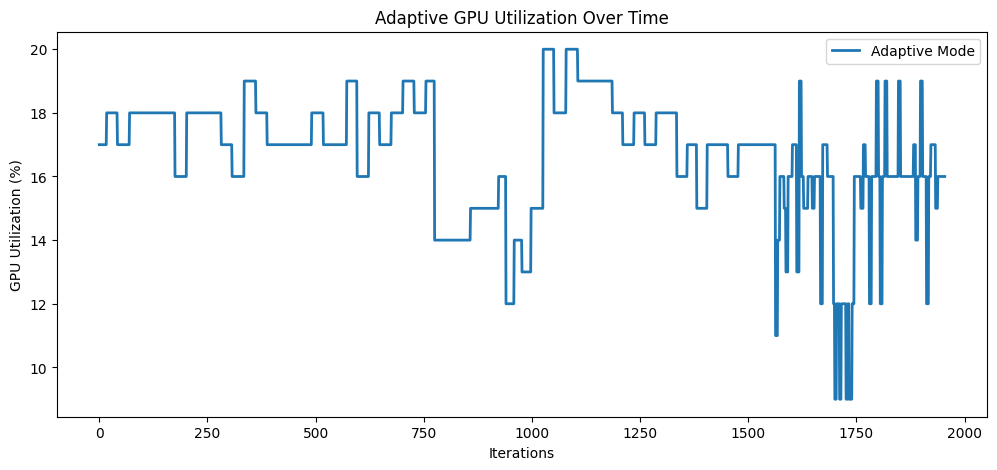

In [18]:
# ===============================
# Graph 3: Adaptive GPU Utilization
# ===============================

plt.figure(figsize=(12,5))

plt.plot(df_adaptive["GPU_Util"], label="Adaptive Mode", linewidth=2)

plt.xlabel("Iterations")
plt.ylabel("GPU Utilization (%)")
plt.title("Adaptive GPU Utilization Over Time")
plt.legend()

plt.show()

Graph 4: Adaptive Batch Size Behavior

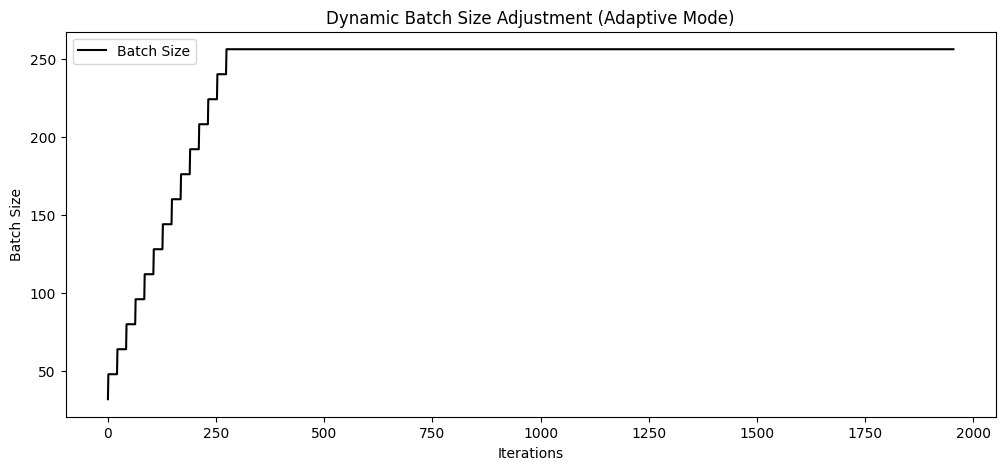

In [19]:
# ===============================
# Graph 4: Adaptive Batch Size Changes
# ===============================

plt.figure(figsize=(12,5))

plt.plot(df_adaptive["Batch_Size"], label="Batch Size", color="black")

plt.xlabel("Iterations")
plt.ylabel("Batch Size")
plt.title("Dynamic Batch Size Adjustment (Adaptive Mode)")
plt.legend()

plt.show()